#### ***Product Segmentation***

#### ***Context***

***Extract insights from the data of men's and women's shoes, and grouping products together to identify similarities and differences between the product range of these renowned brands.***

#### ***Objective***

***To perform an exploratory data analysis and cluster the products based on various factors***

***Data Description***

*The dataset consists of 3268 products from Nike and Adidas with features of information including their ratings, discount, sales price, listed price, product name, and the number of reviews.*

- *`Product Name`: Name of the product*
- *`Product ID`: ID of the product*
- *`Listing Price`: Listed price of the product*
- *`Sale Price`: Sale price of the product*
- *`Discount`: Percentage of discount on the product*
- *`Brand`: Brand of the product*
- *`Rating`: Rating of the product*
- *`Reviews`: Number of reviews for the product*

#### ***Import Libraries***

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme() # sets the seaborn theme for all plots

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute euclidean distances
from scipy.spatial.distance import cdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

pd.set_option("display.max_columns", None) # Removes the limit for the number of displayed columns
pd.set_option("display.max_rows", 200) # Sets the maximum number of displayed rows to 200
pd.set_option("display.float_format", "{:.2f}".format) # Formats floating-point numbers to 2 decimal places

In [2]:
# loading the dataset
data = pd.read_csv("data/37_data_add_nik.csv")

In [3]:
data.shape

(3268, 8)

***The dataset has 3268 rows and 8 columns*** 

In [4]:
# viewing a random sample of the dataset
data.sample(n=10, random_state=1)

,Product Name,Product ID,Listing Price,Sale Price,Discount,Brand,Rating,Reviews
255,Women's adidas Originals POD-S3.1 Shoes,CG6188,13999,6999,50,Adidas ORIGINALS,3.30,8
1551,Men's adidas Originals Superstar Pure Shoes,FV3013,11999,11999,0,Adidas ORIGINALS,3.90,10
1352,Men's adidas Originals Superstar Shoes,FV2806,7999,7999,0,Adidas ORIGINALS,4.40,42
1060,Men's adidas Football Nemeziz 19.3 Indoor Shoes,F34411,5999,3599,40,Adidas SPORT PERFORMANCE,4.50,75
808,Men's adidas Sport Inspired Court 80s Shoes,EE9676,5999,3599,40,Adidas CORE / NEO,4.50,55
836,Men's adidas Running Stargon 1.0 Shoes,CM4935,4799,3839,20,Adidas CORE / NEO,3.50,21
2107,Men's adidas Originals Yung-96 Chasm Shoes,EE7238,7999,4799,40,Adidas ORIGINALS,3.00,62
3002,Nike SB Air Max Stefan Janoski 2,AQ7477-009,0,9995,0,Nike,2.60,11
2329,Men's adidas Originals Rivalry Low Shoes,FV4287,10999,10999,0,Adidas ORIGINALS,2.80,8
602,Men's adidas Sport Inspired Lite Racer RBN Shoes,F36642,5599,3919,30,Adidas CORE / NEO,3.00,56


In [5]:
# copying the data to another variable to avoid any changes to original data
df = data.copy()

In [6]:
# fixing column names
df.columns = [c.replace(" ", "_") for c in df.columns]

In [7]:
# let's look at the structure of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3268 entries, 0 to 3267
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_Name   3268 non-null   object 
 1   Product_ID     3268 non-null   object 
 2   Listing_Price  3268 non-null   int64  
 3   Sale_Price     3268 non-null   int64  
 4   Discount       3268 non-null   int64  
 5   Brand          3268 non-null   object 
 6   Rating         3268 non-null   float64
 7   Reviews        3268 non-null   int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 204.4+ KB


***Dropping `Product_ID` column***

In [8]:
df.drop("Product_ID", axis=1, inplace=True)

In [9]:
# let's check for duplicate observations
df.duplicated().sum()

np.int64(117)

***There are 117 duplicate observations. We will remove them from the data.***

In [10]:
df = df[(~df.duplicated())].copy() # copying excluding duplicate observations

***Statistical Summary***

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Listing_Price,3151.00,7045.96,4652.09,0.00,4599.00,5999.00,8999.00,29999.00
Sale_Price,3151.00,5983.17,4173.71,449.00,2999.00,4599.00,7799.00,36500.00
Discount,3151.00,27.86,22.44,0.00,0.00,40.00,50.00,60.00
Rating,3151.00,3.29,1.37,0.00,2.60,3.60,4.40,5.00
Reviews,3151.00,41.89,31.28,0.00,12.00,40.00,69.00,223.00


***Observations***

- *`Listing_Price` `0` means missing values. Average is more than Median, indicating outliers*
- *`Sale_Price` Average is more than Median, indicating outliers*
- *`Discount` The average discount is 28%.*
- *The average `Rating` is 3.3.*
- *The average number of `Reviews` is 42.*

In [12]:
# let's check how many products have listing price 0
(df.Listing_Price == 0).sum()

np.int64(336)

In [13]:
# let's check the products which have listing price 0
df[(df.Listing_Price == 0)]

,Product_Name,Listing_Price,Sale_Price,Discount,Brand,Rating,Reviews
2625,Nike Air Force 1 '07 Essential,0,7495,0,Nike,0.00,0
2626,Nike Air Force 1 '07,0,7495,0,Nike,0.00,0
2627,Nike Air Force 1 Sage Low LX,0,9995,0,Nike,0.00,0
2628,Nike Air Max Dia SE,0,9995,0,Nike,0.00,0
2629,Nike Air Max Verona,0,9995,0,Nike,0.00,0
...,...,...,...,...,...,...,...
3254,Nike Mercurial Vapor 13 Club MG,0,4995,0,Nike,0.00,0
3257,Air Jordan 5 Retro,0,15995,0,Nike,3.30,3
3260,Nike Tiempo Legend 8 Academy TF,0,6495,0,Nike,0.00,0
3262,Nike React Metcon AMP,0,13995,0,Nike,3.00,1


***There are 336 rows (which is close to 10% of the given data) where Listing Price is missing, Lets explore other details when Listing Price is zero***

In [14]:
df[(df.Listing_Price == 0)].describe().T

,count,mean,std,min,25%,50%,75%,max
Listing_Price,336.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Sale_Price,336.00,11203.05,4623.83,1595.00,7995.00,10995.00,13995.00,36500.00
Discount,336.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Rating,336.00,2.80,2.15,0.00,0.00,3.95,4.70,5.00
Reviews,336.00,8.26,19.71,0.00,0.00,1.00,6.00,223.00


***We see that the discount for the products with listing price 0 is 0. So, we will replace the listing price with the corresponding sale price for those observations.***

In [15]:
# df.loc[(df.Listing_Price == 0), ["Listing_Price"]] = df.loc[(df.Listing_Price == 0), ["Sale_Price"]].values

df["Listing_Price"] = np.where(df["Listing_Price"] == 0, df["Sale_Price"], df["Listing_Price"])

In [16]:
df.Listing_Price.describe()

count    3151.00
mean     8240.57
std      4363.02
min       899.00
25%      4999.00
50%      7599.00
75%     10995.00
max     36500.00
Name: Listing_Price, dtype: float64

In [17]:
# checking missing values
df.isna().sum()

Product_Name     0
Listing_Price    0
Sale_Price       0
Discount         0
Brand            0
Rating           0
Reviews          0
dtype: int64

***There are no missing values in the data.***

#### ***Exploratory Data Analysis***

In [18]:
# function to analyze a single numeric feature, creates boxplot, histogram, and CDF
def univariate_num_analysis_box_hist_cdf(data, feature, figsize=(12, 6)):
    """
    Display:
      - Left column: Boxplot (top) and Histogram (bottom)
      - Right column: CDF plot
    for a single numeric feature.
    
    Parameters:
    - data : pandas DataFrame
    - feature : str, numeric column name
    - figsize : tuple, figure size
    """
    fig = plt.figure(figsize=figsize)
    # Create grid: 2 rows, 2 columns
    grid = fig.add_gridspec(2, 2, width_ratios=(3, 2), height_ratios=(0.4, 1))

    # 1️⃣ Boxplot (top left)
    ax_box = fig.add_subplot(grid[0, 0])
    sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, color="lightgreen")
    ax_box.set_title(f'Boxplot of {feature}')

    # 2️⃣ Histogram (bottom left)
    ax_hist = fig.add_subplot(grid[1, 0])
    sns.histplot(data=data, x=feature, kde=True, ax=ax_hist, color='skyblue')
    ax_hist.axvline(data[feature].mean(), color="green", linestyle="--", label="Mean")
    ax_hist.axvline(data[feature].median(), color="black", linestyle="-", label="Median")
    ax_hist.set_title(f'Histogram of {feature}')
    ax_hist.legend()

    # 3️⃣ CDF Plot (right column, spans both rows)
    ax_cdf = fig.add_subplot(grid[:, 1])  # span both rows in column 2
    sns.ecdfplot(data=data, x=feature, ax=ax_cdf, color='orange')
    ax_cdf.set_title(f'CDF of {feature}')
    ax_cdf.set_ylabel("Cumulative Probability")
    ax_cdf.grid(True)

    plt.tight_layout()
    plt.show()

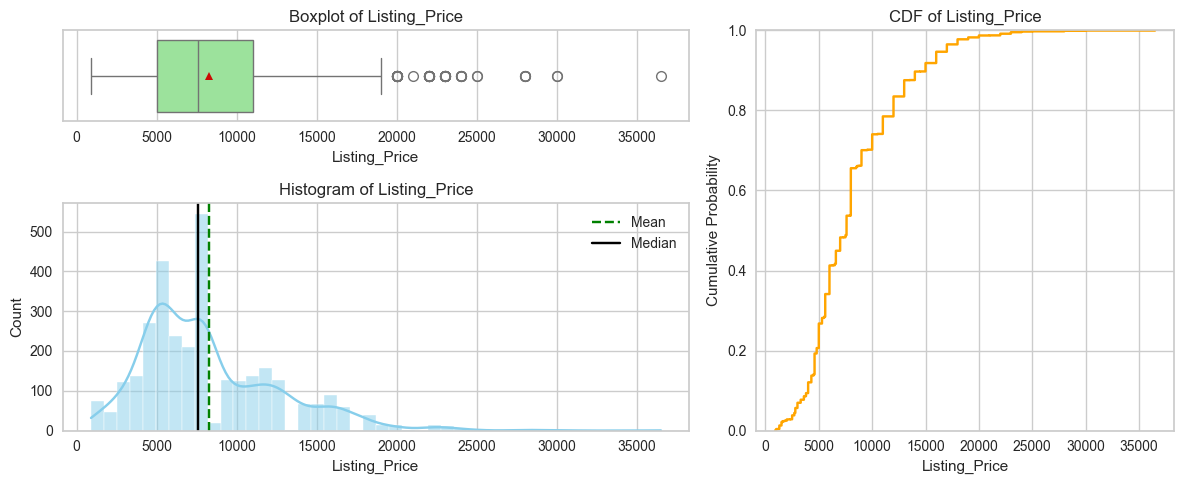

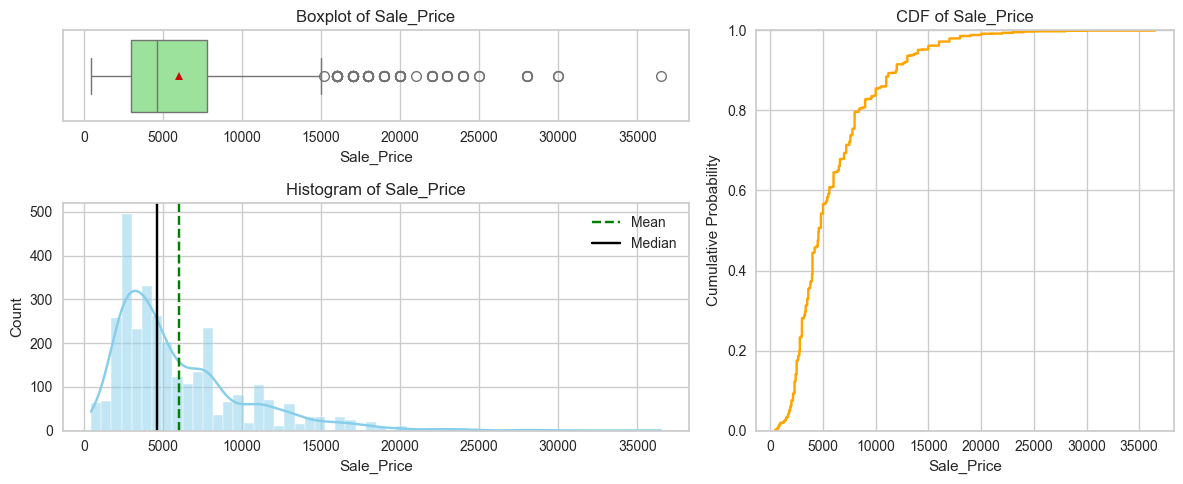

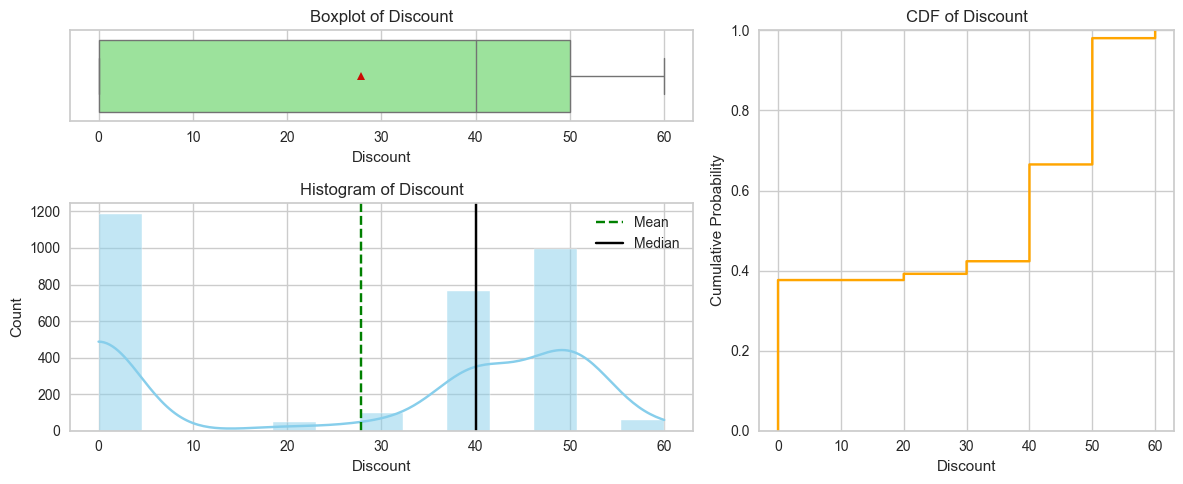

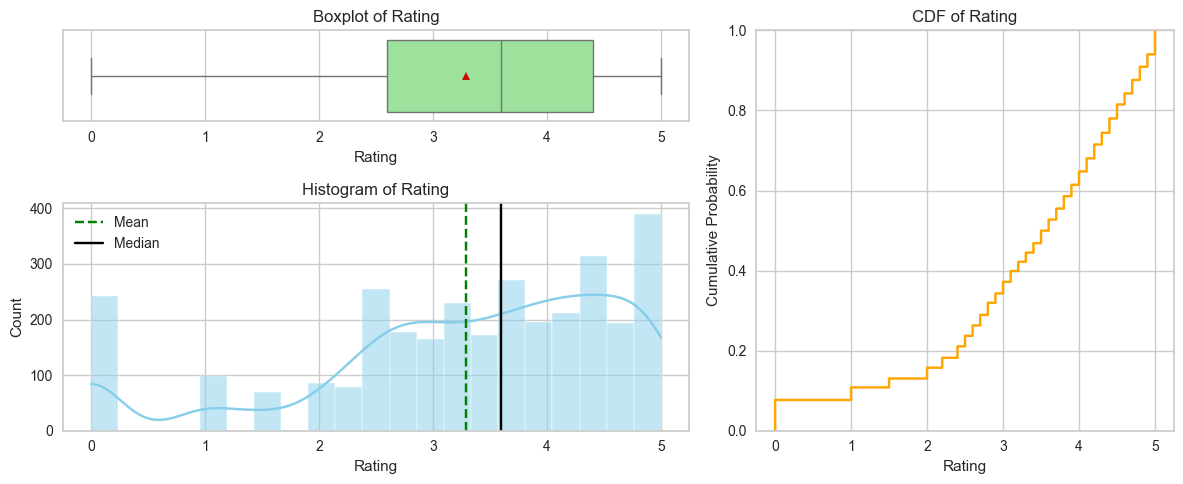

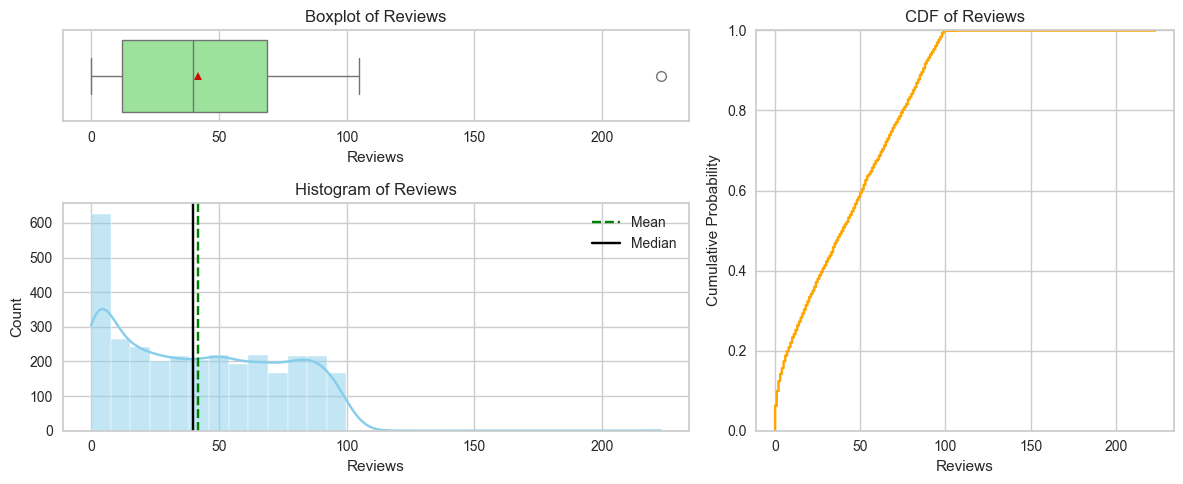

In [19]:
# selecting numerical columns
num_col = df.select_dtypes(include=np.number).columns.tolist()

for item in num_col:
    univariate_num_analysis_box_hist_cdf(df, item, figsize=(12, 5))

***Observations***

- *`Listing_Price` right skewed, upper outliers, almost 90% listing price less than 15000*
- *`Sale_Price` right skewed, upper outliers, almost 95% of sale price less than 15000*
- *`Discount` Almost 40% products have no discounts.* 
- *`Rating` around 40% products have less than 3 rating*
- *`Reviews` Total number of reviews for products are less than 100*

***Helper Function to create Barplot***

In [20]:
# Function to plot count and percentage barplots side by side for categorical features for Univariate Analysis
def cat_analysis_count_and_perct(data, column, figsize=(10, 5)):
    """
    Plots two countplots side by side: one with count labels, one with percentage labels.
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        column (str): The column to plot.
        figsize (tuple): Figure size for the plots.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    categories = data[column].value_counts().index
    total = len(data)
    
    # Countplot with count labels
    ax1 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[0], palette='Set2')
    axes[0].set_title('Counts per ' + column)
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=90)
    for p in ax1.patches:
        count = int(p.get_height())
        ax1.annotate(str(count), (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black')
    
    # Countplot with percentage labels
    ax2 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[1], palette='Set2')
    axes[1].set_title('Percentage per ' + column)
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Percentage')
    axes[1].tick_params(axis='x', rotation=90)
    for p in ax2.patches:
        percent = 100 * p.get_height() / total
        ax2.annotate(f'{percent:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='blue')
    
    plt.tight_layout()
    plt.show()

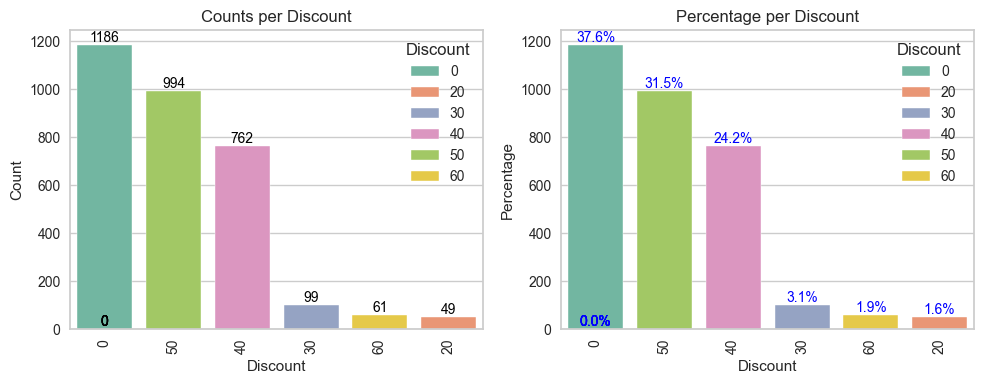

In [21]:
# let's explore discounts further
cat_analysis_count_and_perct(df, "Discount", figsize=(10, 4))

***Observations***

- *37.6% of products did not have any discounts.*
- *More than 50% of the products have 40-50% discount.*

#### ***Bivariate Analysis***

***Checking for correlations***

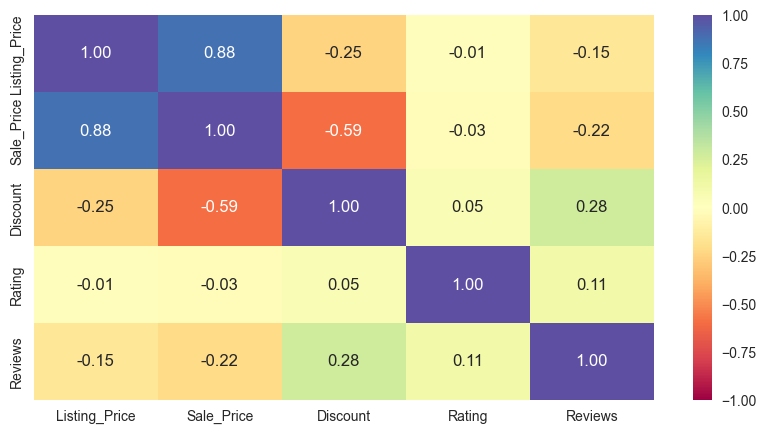

In [22]:
plt.figure(figsize=(10, 5))
sns.heatmap(df[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

***Observations***

- *The sale price and the listing price are highly positively correlated, which is obvious.*
- *Discount is somewhat negatively correlated with listing price or sale price, which indicates that expensive products either have fewer discounts or no discounts at all.*

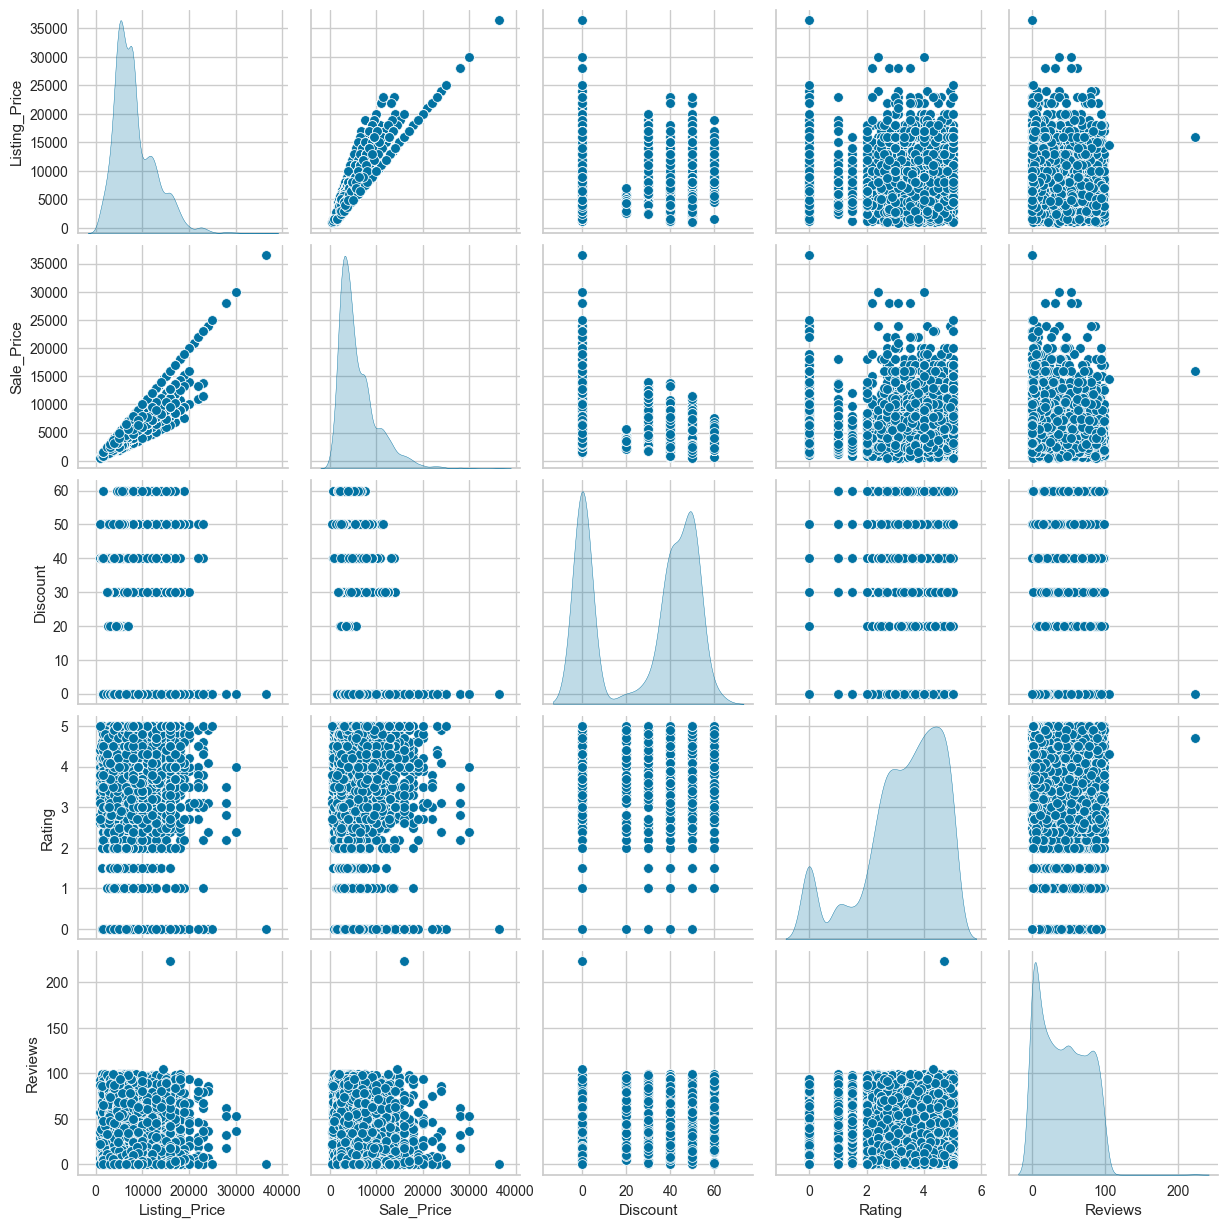

In [23]:
sns.pairplot(data=df[num_col], diag_kind="kde")
plt.show()

***Observations***

- *KDE plot clearly shows meaningful clusters across features*

#### ***Data Preprocessing***

In [24]:
# variables used for clustering
num_col

['Listing_Price', 'Sale_Price', 'Discount', 'Rating', 'Reviews']

In [25]:
# scaling the dataset before clustering
scaler = StandardScaler()
subset = df[num_col].copy()
subset_scaled = scaler.fit_transform(subset)

In [26]:
# creating a dataframe of the scaled columns
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

### ***K-means Clustering***

Number of Clusters: 1 	Average Distortion: 2.0907211006458244
Number of Clusters: 2 	Average Distortion: 1.712012896274925
Number of Clusters: 3 	Average Distortion: 1.5777557596295235
Number of Clusters: 4 	Average Distortion: 1.4461304305560199
Number of Clusters: 5 	Average Distortion: 1.308144368052669
Number of Clusters: 6 	Average Distortion: 1.2290833106452994
Number of Clusters: 7 	Average Distortion: 1.1680734325277613
Number of Clusters: 8 	Average Distortion: 1.1014111489770062


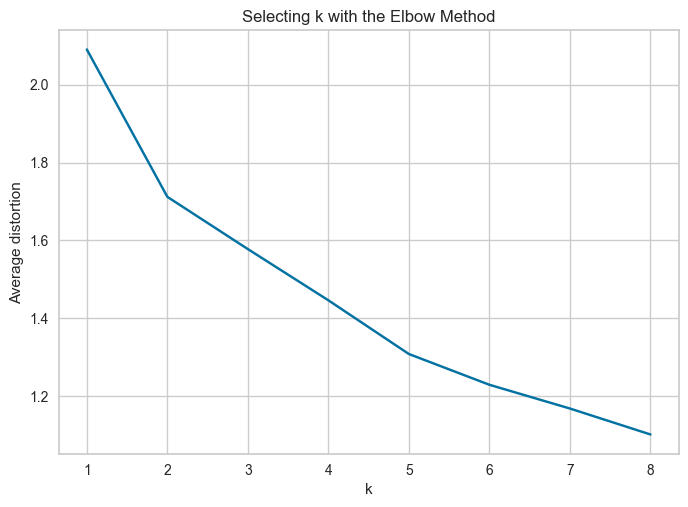

In [27]:
clusters = range(1, 9)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k)
    model.fit(subset_scaled_df)
    prediction = model.predict(subset_scaled_df)
    avg_distortion = (
        sum(
            np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1)
        )
        / subset_scaled_df.shape[0]
    )

    meanDistortions.append(avg_distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", avg_distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average distortion")
plt.title("Selecting k with the Elbow Method")
plt.show()

***Appropriate value for k seems to be 2 or 6.***

***Let's check the silhouette scores.***

For n_clusters = 2, the silhouette score is 0.33462520494927556)
For n_clusters = 3, the silhouette score is 0.21834704859891807)
For n_clusters = 4, the silhouette score is 0.2409818355832576)
For n_clusters = 5, the silhouette score is 0.2703428547575843)
For n_clusters = 6, the silhouette score is 0.28141093710519577)
For n_clusters = 7, the silhouette score is 0.2912160431876738)
For n_clusters = 8, the silhouette score is 0.28446548560801466)
For n_clusters = 9, the silhouette score is 0.2890605439082896)


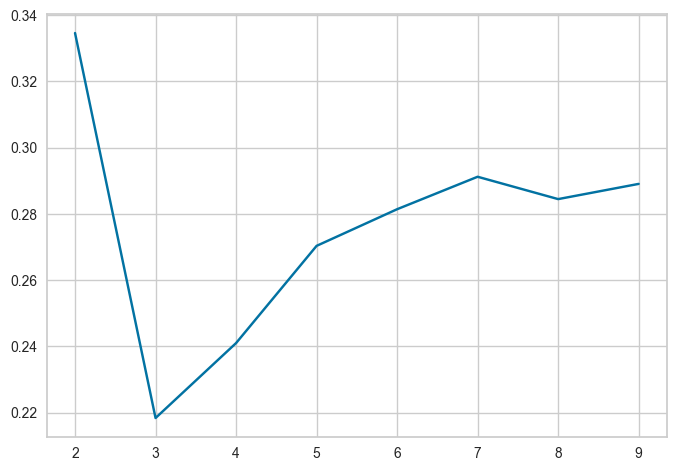

In [28]:
sil_score = []
cluster_list = list(range(2, 10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict((subset_scaled_df))
    # centers = clusterer.cluster_centers_
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

***Silhouette score for 4 is higher than others, we will choose 4 as value of k.***

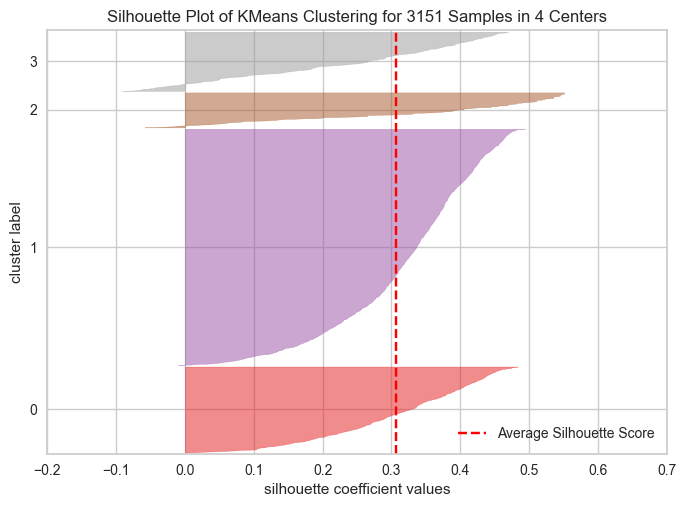

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 3151 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [29]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1)) # visual breakdown of silhouette scores for each cluster
visualizer.fit(subset_scaled_df)
visualizer.show()

In [30]:
# let's take 4 as number of clusters
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(subset_scaled_df)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [31]:
# adding kmeans cluster labels to the original and scaled dataframes

df["K_means_segments"] = kmeans.labels_
subset_scaled_df["K_means_segments"] = kmeans.labels_

#### ***Cluster Profiling***

In [32]:
cluster_profile = df.groupby("K_means_segments").mean(numeric_only=True)

In [33]:
cluster_profile["count_in_each_segments"] = (
    df.groupby("K_means_segments")["Sale_Price"].count().values
)

In [34]:
# let's display cluster profiles
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Listing_Price,Sale_Price,Discount,Rating,Reviews,count_in_each_segments
K_means_segments,,,,,,
0,9725.996255,8331.101124,7.715356,0.255805,11.898876,267
1,6629.654600,6275.108597,0.935143,3.800302,39.104072,663
2,6801.853945,3688.562955,45.433688,3.390319,50.137101,1787
3,15711.592166,13540.774194,9.032258,3.932719,30.647465,434


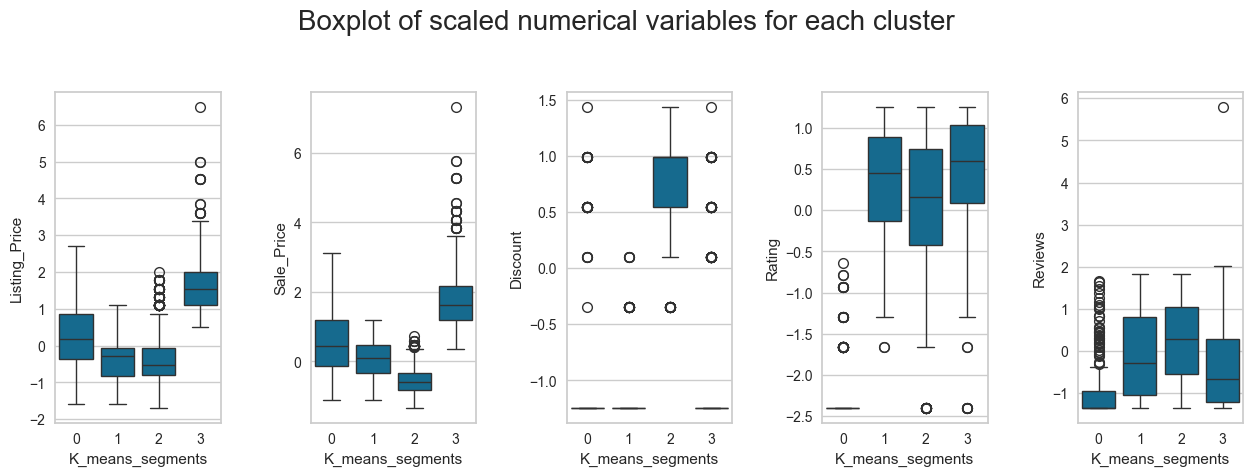

In [35]:
fig, axes = plt.subplots(1, 5, figsize=(13, 5))
fig.suptitle("Boxplot of scaled numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(
        ax=axes[ii],
        y=subset_scaled_df[num_col[counter]],
        x=subset_scaled_df["K_means_segments"],
        # hue=subset_scaled_df["K_means_segments"],
    )
    counter = counter + 1

fig.tight_layout(pad=2.0)

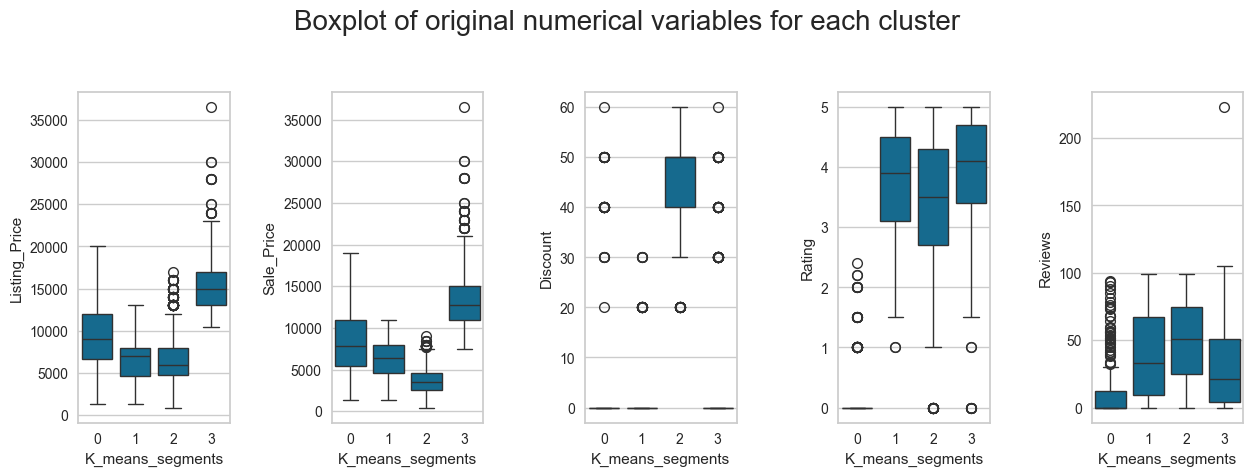

In [36]:
fig, axes = plt.subplots(1, 5, figsize=(13, 5))
fig.suptitle("Boxplot of original numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii], y=df[num_col[counter]], x=df["K_means_segments"])
    counter = counter + 1

fig.tight_layout(pad=2.0)

#### ***Insights***

- ***Cluster 3***:
    - *This cluster contains more expensive premium products, with an average listing price of approximately 15500.*
    - *Almost no discount is given to products in this cluster.*
    - *The median rating of this cluster is around 4 suggesting that customers are very satisfied with 50% of the products in this cluster.*
    - *Products in these clusters have got lesser reviews, which can be because these products are very expensive and fewer people buy them.*
   
- ***Cluster 2***:
    - *Listing price is low for products in this cluster, and the sale price is lower, as there are heavier discounts on these products.*
    - *50% of the products have discounts between 30% to 40%.*
    - *More than 50% of products have a rating from 2.5 to 4.5 which indicates that customer satisfaction varies across products in this cluster.*
    - *On average, 50 reviews are given to products in this cluster.*
    
- ***Cluster 1***:
    - *The listing price of products in this cluster is similar to those in Cluster 1, but the sale price is comparatively higher as there are almost no discounts.*
    - *On average, 38 reviews are given to products in this cluster.*


- ***Cluster 0***:
    - *Listing and sale price of products in this cluster suggest that these are medium-range products.*
    - *Almost no discount is given to products in this cluster.*
    - *Products in this cluster have a low rating or no rating at all.*